# Bronx Evaluating the Final Model on 2025-03-01 to 2026-02-28

We had initially held out 2025-03-01 to 2026-02-28. We shall use TimeSeriesSplit to see how our chosen model performs. We have chosen Prophet for Bronx since the other models did not provide any improvement while also increasing modeling complexity greatly.

## Import and Load Data

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

In [49]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to BRONX

rs = rs[rs['borough']=='BRONX']

## Drop the column with borough

rs = rs.drop(columns=['borough'])


In [50]:
rs['created_date'] = pd.to_datetime(rs['created_date'])
start = rs['created_date'].min()
end = rs['created_date'].max()
rs = (rs.set_index('created_date').reindex(pd.date_range(start, end, freq='D'), fill_value=0).rename_axis('created_date').reset_index())
rs

,created_date,count
0,2020-01-01,3
1,2020-01-02,7
2,2020-01-03,10
3,2020-01-04,4
4,2020-01-05,4
...,...,...
2246,2026-02-24,4
2247,2026-02-25,7
2248,2026-02-26,10
2249,2026-02-27,12


In [51]:
# Create a date range covering 2020 to end
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

## Evaluate the Model

In [52]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    y_pred = np.round(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)

16:30:01 - cmdstanpy - INFO - Chain [1] start processing
16:30:01 - cmdstanpy - INFO - Chain [1] done processing
16:30:02 - cmdstanpy - INFO - Chain [1] start processing
16:30:02 - cmdstanpy - INFO - Chain [1] done processing
16:30:02 - cmdstanpy - INFO - Chain [1] start processing
16:30:03 - cmdstanpy - INFO - Chain [1] done processing
16:30:03 - cmdstanpy - INFO - Chain [1] start processing
16:30:03 - cmdstanpy - INFO - Chain [1] done processing
16:30:04 - cmdstanpy - INFO - Chain [1] start processing
16:30:04 - cmdstanpy - INFO - Chain [1] done processing
16:30:04 - cmdstanpy - INFO - Chain [1] start processing
16:30:04 - cmdstanpy - INFO - Chain [1] done processing
16:30:05 - cmdstanpy - INFO - Chain [1] start processing
16:30:05 - cmdstanpy - INFO - Chain [1] done processing
16:30:06 - cmdstanpy - INFO - Chain [1] start processing
16:30:06 - cmdstanpy - INFO - Chain [1] done processing
16:30:06 - cmdstanpy - INFO - Chain [1] start processing
16:30:06 - cmdstanpy - INFO - Chain [1]

## Results

In [53]:
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

In [54]:
prophet_results_df

,fold,rmse,mape
0,0,4.350698,3.564776e-01
1,1,3.370036,2.173870e-01
2,2,4.234214,2.502449e-01
3,3,4.284524,8.109959e-01
4,4,4.342481,5.353698e-01
5,5,2.236068,1.937204e-01
6,6,5.182388,6.063431e-01
7,7,3.779645,2.720180e-01
8,8,4.367085,1.968502e-01
9,9,5.451081,2.927693e-01


## Plots

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_5062/1073609526.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['fold'] = df_plot['fold'].astype(int)


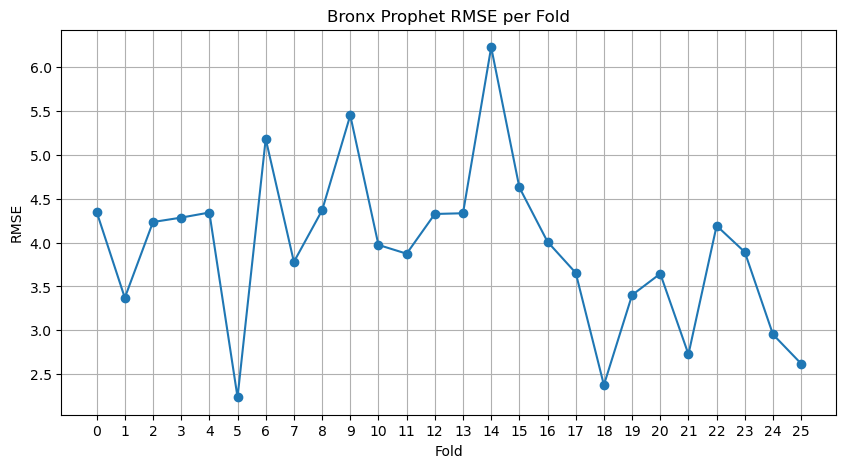

In [55]:
import matplotlib.pyplot as plt

# Drop the 'mean' row
df_plot = prophet_results_df[prophet_results_df['fold'] != 'mean']

# Convert fold to integer (just to be safe)
df_plot['fold'] = df_plot['fold'].astype(int)

# Plot RMSE per fold
plt.figure(figsize=(10, 5))
plt.plot(df_plot['fold'], df_plot['rmse'], marker='o', linestyle='-')
plt.title("Bronx Prophet RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(df_plot['fold'])
plt.grid(True)
plt.show()


# Queens Evaluating the Final Model on 2025-03-01 to 2026-02-28

We had initially held out 2025-03-01 to 2026-02-28. We shall use TimeSeriesSplit to see how our chosen model performs. We have chosen Prophet for Staten Island since the other models did not provide any improvement while also increasing modeling complexity greatly.

## Import and Load Data

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

In [57]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to QUEENS

rs = rs[rs['borough']=='QUEENS']

## Drop the column with borough

rs = rs.drop(columns=['borough'])


In [58]:
rs['created_date'] = pd.to_datetime(rs['created_date'])
start = rs['created_date'].min()
end = rs['created_date'].max()
rs = (rs.set_index('created_date').reindex(pd.date_range(start, end, freq='D'), fill_value=0).rename_axis('created_date').reset_index())
rs

,created_date,count
0,2020-01-01,2
1,2020-01-02,4
2,2020-01-03,1
3,2020-01-04,3
4,2020-01-05,3
...,...,...
2246,2026-02-24,2
2247,2026-02-25,5
2248,2026-02-26,5
2249,2026-02-27,4


In [59]:
# Create a date range covering 2020 to end
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

## Evaluate the Model

In [60]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    y_pred = np.round(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)

16:30:21 - cmdstanpy - INFO - Chain [1] start processing
16:30:21 - cmdstanpy - INFO - Chain [1] done processing
16:30:22 - cmdstanpy - INFO - Chain [1] start processing
16:30:22 - cmdstanpy - INFO - Chain [1] done processing
16:30:23 - cmdstanpy - INFO - Chain [1] start processing
16:30:23 - cmdstanpy - INFO - Chain [1] done processing
16:30:24 - cmdstanpy - INFO - Chain [1] start processing
16:30:24 - cmdstanpy - INFO - Chain [1] done processing
16:30:25 - cmdstanpy - INFO - Chain [1] start processing
16:30:25 - cmdstanpy - INFO - Chain [1] done processing
16:30:26 - cmdstanpy - INFO - Chain [1] start processing
16:30:26 - cmdstanpy - INFO - Chain [1] done processing
16:30:27 - cmdstanpy - INFO - Chain [1] start processing
16:30:27 - cmdstanpy - INFO - Chain [1] done processing
16:30:28 - cmdstanpy - INFO - Chain [1] start processing
16:30:28 - cmdstanpy - INFO - Chain [1] done processing
16:30:29 - cmdstanpy - INFO - Chain [1] start processing
16:30:29 - cmdstanpy - INFO - Chain [1]

## Results

In [61]:
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

In [62]:
prophet_results_df

,fold,rmse,mape
0,0,4.472136,4.549073e-01
1,1,2.725541,3.545316e-01
2,2,3.882194,3.369102e-01
3,3,3.240370,3.596226e-01
4,4,3.240370,3.843685e-01
5,5,4.598136,7.238301e-01
6,6,3.575712,3.766137e-01
7,7,4.234214,3.136613e-01
8,8,4.174754,3.620409e-01
9,9,4.743416,4.996665e-01


## Plots

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_5062/2626269471.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['fold'] = df_plot['fold'].astype(int)


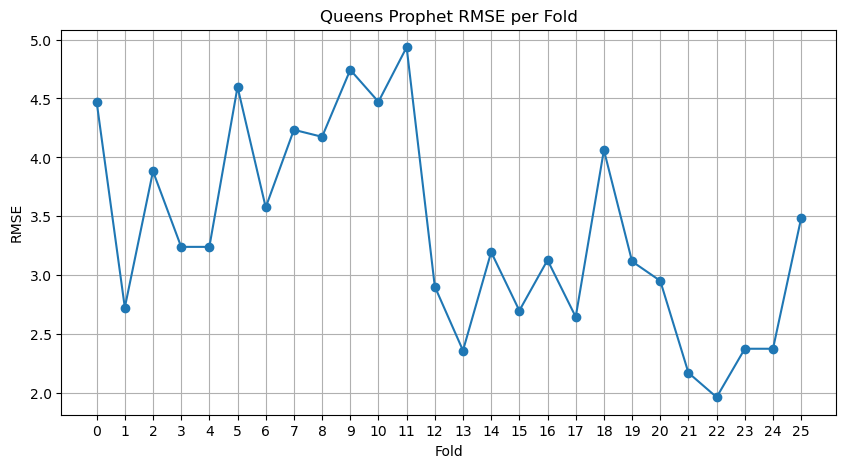

In [63]:
import matplotlib.pyplot as plt

# Drop the 'mean' row
df_plot = prophet_results_df[prophet_results_df['fold'] != 'mean']

# Convert fold to integer (just to be safe)
df_plot['fold'] = df_plot['fold'].astype(int)

# Plot RMSE per fold
plt.figure(figsize=(10, 5))
plt.plot(df_plot['fold'], df_plot['rmse'], marker='o', linestyle='-')
plt.title("Queens Prophet RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(df_plot['fold'])
plt.grid(True)
plt.show()
